In [241]:
import pandas as pd
import matplotlib
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np  # likely needed too

# Clear and rebuild cache
import shutil, os
cache = matplotlib.get_cachedir()
shutil.rmtree(cache, ignore_errors=True)
os.makedirs(cache, exist_ok=True)

# Manually register DejaVu fonts
font_dir = "/opt/homebrew/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf"
for ttf in os.listdir(font_dir):
    if ttf.endswith(".ttf"):
        fm.fontManager.addfont(os.path.join(font_dir, ttf))

# Set as default
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

print("Fonts loaded, good to go!")

Fonts loaded, good to go!


## Pretraining

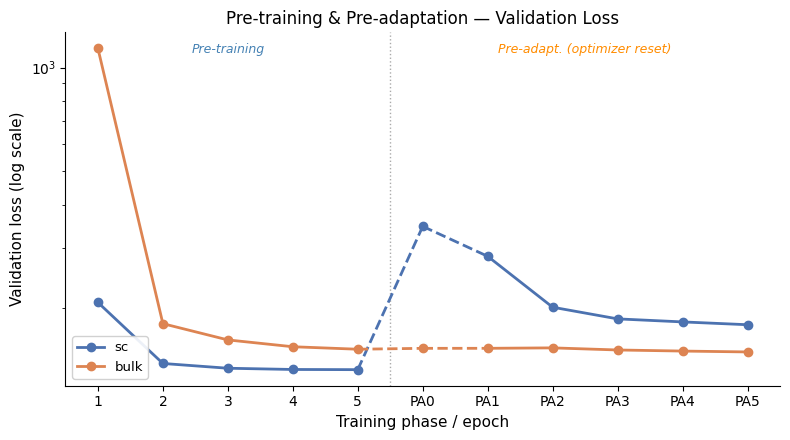

In [242]:
root = os.path.expanduser("~/Thesis/eheiss/output")

def load_val(path):
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    val = df[df["split"] == "val"].reset_index(drop=True)
    return val if not val.empty else None

series = {
    "sc": {
        "pretrain": load_val(f"{root}/pretrain_sc/pretrain_sc_pretrain_epoch_metrics.csv"),
        "pa0": load_val(f"{root}/preadapt_sc/preadapt_sc_pa0_epoch_metrics.csv"),
        "preadapt": load_val(f"{root}/preadapt_sc/preadapt_sc_pretrain_epoch_metrics.csv"),
        "color": "#4C72B0",
    },
    "bulk": {
        "pretrain": load_val(f"{root}/pretrain_bulk/pretrain_bulk_pretrain_epoch_metrics.csv"),
        "pa0": load_val(f"{root}/preadapt_bulk/preadapt_bulk_pa0_epoch_metrics.csv"),
        "preadapt": load_val(f"{root}/preadapt_bulk/preadapt_bulk_pretrain_epoch_metrics.csv"),
        "color": "#DD8452",
    },
}
series = {name: values for name, values in series.items()
          if any(values[key] is not None for key in ("pretrain", "pa0", "preadapt"))}
if not series:
    raise FileNotFoundError(f"No pre-training, PA0, or pre-adaptation metric files found under {root}")

pretrain_epochs = sorted({epoch for values in series.values()
                          if values["pretrain"] is not None
                          for epoch in values["pretrain"]["epoch"]})
pretrain_end = max(pretrain_epochs, default=0)
has_pa0 = any(values["pa0"] is not None for values in series.values())
pa0_tick = pretrain_end + 1 if has_pa0 else None
preadapt_epochs = sorted({epoch for values in series.values()
                          if values["preadapt"] is not None
                          for epoch in values["preadapt"]["epoch"]})
preadapt_offset = pretrain_end + (1 if has_pa0 else 0)
preadapt_ticks = [preadapt_offset + epoch for epoch in preadapt_epochs]
sep = pretrain_end + 0.5

fig, ax = plt.subplots(figsize=(8, 4.5))

for name, values in series.items():
    df_pt = values["pretrain"]
    df_pa0 = values["pa0"]
    df_pa = values["preadapt"]
    color = values["color"]
    last_x = None
    last_y = None

    if df_pt is not None:
        ax.plot(df_pt["epoch"], df_pt["loss"], color=color, marker="o",
                lw=2, zorder=3, label=name)
        last_x = float(df_pt["epoch"].iloc[-1])
        last_y = float(df_pt["loss"].iloc[-1])

    if df_pa0 is not None and pa0_tick is not None:
        pa0_loss = float(df_pa0["loss"].iloc[0])
        if last_x is not None:
            ax.plot([last_x, pa0_tick], [last_y, pa0_loss],
                    color=color, lw=2, ls="--", zorder=3)
        ax.plot([pa0_tick], [pa0_loss], color=color, marker="o", lw=0, zorder=4,
                label=name if df_pt is None else "_nolegend_")
        last_x = float(pa0_tick)
        last_y = pa0_loss

    if df_pa is not None:
        pa_x = preadapt_offset + df_pa["epoch"].to_numpy()
        if last_x is not None:
            ax.plot([last_x, pa_x[0]], [last_y, df_pa["loss"].iloc[0]],
                    color=color, lw=2, ls="--", zorder=3)
        ax.plot(pa_x, df_pa["loss"], color=color, marker="o", lw=2, zorder=3,
                label=name if df_pt is None and df_pa0 is None else "_nolegend_")

if pretrain_epochs and (has_pa0 or preadapt_epochs):
    ax.axvline(sep, color="#aaaaaa", ls=":", lw=1)
if pretrain_epochs:
    ax.text(np.mean(pretrain_epochs), 0.97, "Pre-training",
            transform=ax.get_xaxis_transform(), ha="center", va="top",
            fontsize=9, color="steelblue", style="italic")
pa_phase_ticks = ([pa0_tick] if pa0_tick is not None else []) + preadapt_ticks
if pa_phase_ticks:
    ax.text(np.mean(pa_phase_ticks), 0.97, "Pre-adapt. (optimizer reset)",
            transform=ax.get_xaxis_transform(), ha="center", va="top",
            fontsize=9, color="darkorange", style="italic")

xticks = pretrain_epochs + ([pa0_tick] if pa0_tick is not None else []) + preadapt_ticks
xlabels = [str(e) for e in pretrain_epochs] + (["PA0"] if pa0_tick is not None else []) + [f"PA{e}" for e in preadapt_epochs]
ax.set_yscale("log")
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)
ax.set_xlabel("Training phase / epoch", fontsize=11)
ax.set_ylabel("Validation loss (log scale)", fontsize=11)
ax.set_title("Pre-training & Pre-adaptation — Validation Loss", fontsize=12)
ax.legend(loc="lower left", fontsize=9.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Cancer classification (5 types)

In [243]:
bulkrnabert_weighted_f1_mean = 0.993
bulkrnabert_weighted_f1_sd = 0.004

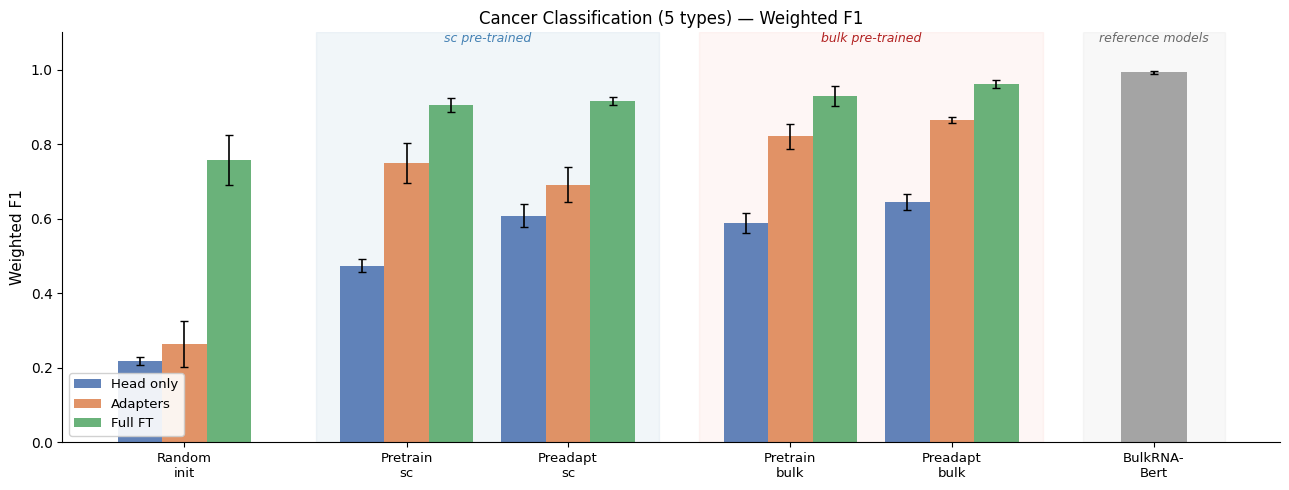

In [244]:
task = "canc_type_class"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft"]
mode_labels = {"head_only": "Head only", "adapters": "Adapters", "full_ft": "Full FT"}
colors  = {"head_only": "#4C72B0", "adapters": "#DD8452", "full_ft": "#55A868"}

dfs = {}
for mode in modes:
    path = f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv"
    if os.path.exists(path):
        dfs[mode] = pd.read_csv(path, comment="#").set_index("model")
available_modes = [mode for mode in modes if mode in dfs]
if not available_modes:
    raise FileNotFoundError(f"No evaluation metric files found under {base}")

bar_w = 0.22
centers = {
    "random_init":  0.0,
    "pretrain_sc":  1.1,
    "preadapt_sc":  1.9,
    "pretrain_bulk": 3.0,
    "preadapt_bulk": 3.8,
}
brnabert_x = 4.8

fig, ax = plt.subplots(figsize=(13, 5))

added = set()
for m_idx, mode in enumerate(available_modes):
    offset = (m_idx - (len(available_modes) - 1) / 2) * bar_w
    for model, xc in centers.items():
        if model not in dfs[mode].index:
            continue
        mean = dfs[mode].loc[model, "f1_weighted_mean"]
        std  = dfs[mode].loc[model, "f1_weighted_std"]
        lbl  = mode_labels[mode] if mode not in added else ""
        ax.bar(xc + offset, mean, bar_w, yerr=std, color=colors[mode],
               capsize=3, alpha=0.88, label=lbl, error_kw={"linewidth": 1.2})
        added.add(mode)

# BulkRNABert reference bar
ax.bar(brnabert_x, bulkrnabert_weighted_f1_mean, bar_w * 1.5, yerr=bulkrnabert_weighted_f1_sd, capsize=3,
       color="#999999", alpha=0.88, label="_nolegend_")

sc_lo,   sc_hi   = centers["pretrain_sc"]  - 0.45, centers["preadapt_sc"]  + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
ref_lo,  ref_hi  = brnabert_x - 0.35, brnabert_x + 0.35
ax.axvspan(sc_lo,   sc_hi,   alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon",    zorder=0)
ax.axvspan(ref_lo,  ref_hi,  alpha=0.05, color="gray",      zorder=0)

y_lim = (0, 1.1)
ax.set_ylim(*y_lim)

ax.text((sc_lo + sc_hi) / 2,     y_lim[1] - 0.0003, "sc pre-trained",
        ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_lim[1] - 0.0003, "bulk pre-trained",
        ha="center", va="top", fontsize=9, color="firebrick", style="italic")
ax.text((ref_lo + ref_hi) / 2,   y_lim[1] - 0.0003, "reference models",
        ha="center", va="top", fontsize=9, color="dimgray", style="italic")

tick_pos    = list(centers.values()) + [brnabert_x]
tick_labels = ["Random\ninit", "Pretrain\nsc", "Preadapt\nsc",
               "Pretrain\nbulk", "Preadapt\nbulk", "BulkRNA-\nBert"]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=9.5)

ax.set_ylabel("Weighted F1", fontsize=11)
ax.set_title("Cancer Classification (5 types) — Weighted F1", fontsize=12)
ax.legend(loc="lower left", fontsize=9.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


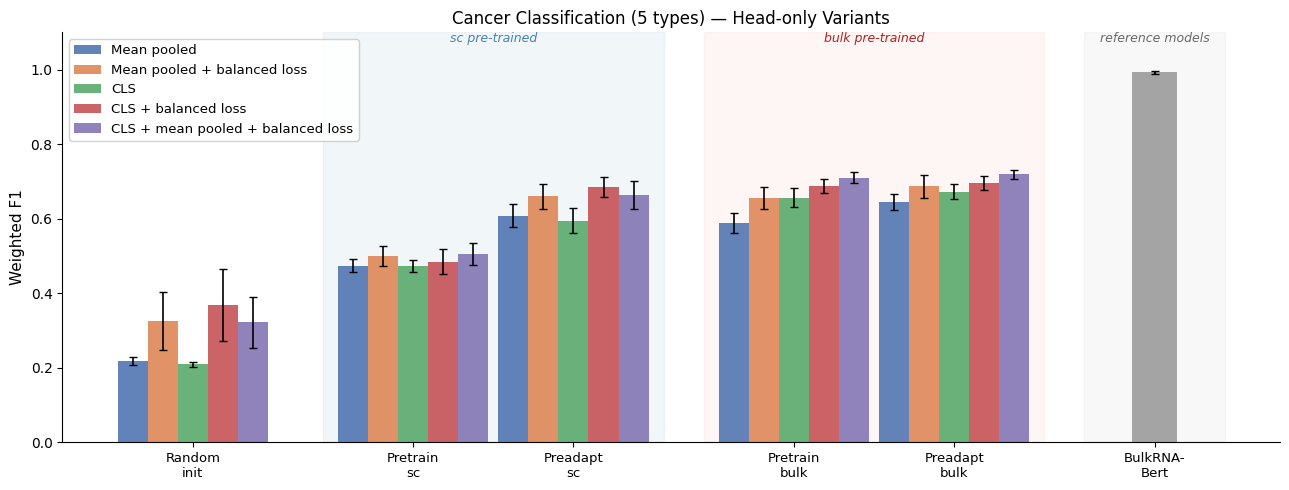

In [245]:
task = "canc_type_class"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
variants = ["head_only", "head_only_balanced", "head_only_cls", "head_only_balanced_cls", "head_only_balanced_mean_cls"]
variant_labels = {
    "head_only": "Mean pooled",
    "head_only_balanced": "Mean pooled + balanced loss",
    "head_only_cls": "CLS",
    "head_only_balanced_cls": "CLS + balanced loss",
    "head_only_balanced_mean_cls": "CLS + mean pooled + balanced loss",
}
colors = {
    "head_only": "#4C72B0",
    "head_only_balanced": "#DD8452",
    "head_only_cls": "#55A868",
    "head_only_balanced_cls": "#C44E52",
    "head_only_balanced_mean_cls": "#8172B3",
}

dfs = {}
for variant in variants:
    path = f"{base}/{variant}/{task}_{variant}_evaluation_metrics.csv"
    if os.path.exists(path):
        dfs[variant] = pd.read_csv(path, comment="#").set_index("model")
available_variants = [variant for variant in variants if variant in dfs]
if not available_variants:
    raise FileNotFoundError(f"No head-only evaluation metric files found under {base}")

bar_w = 0.15
centers = {
    "random_init": 0.0,
    "pretrain_sc": 1.1,
    "preadapt_sc": 1.9,
    "pretrain_bulk": 3.0,
    "preadapt_bulk": 3.8,
}
brnabert_x = 4.8

fig, ax = plt.subplots(figsize=(13, 5))

added = set()
for variant_idx, variant in enumerate(available_variants):
    offset = (variant_idx - (len(available_variants) - 1) / 2) * bar_w
    for model, xc in centers.items():
        if model not in dfs[variant].index:
            continue
        mean = dfs[variant].loc[model, "f1_weighted_mean"]
        std = dfs[variant].loc[model, "f1_weighted_std"]
        label = variant_labels[variant] if variant not in added else ""
        ax.bar(
            xc + offset, mean, bar_w, yerr=std, color=colors[variant],
            capsize=3, alpha=0.88, label=label,
            error_kw={"linewidth": 1.2},
        )
        added.add(variant)

ax.bar(
    brnabert_x, bulkrnabert_weighted_f1_mean, bar_w * 1.5,
    yerr=bulkrnabert_weighted_f1_sd, capsize=3, color="#999999",
    alpha=0.88, label="_nolegend_",
)

sc_lo, sc_hi = centers["pretrain_sc"] - 0.45, centers["preadapt_sc"] + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
ref_lo, ref_hi = brnabert_x - 0.35, brnabert_x + 0.35
ax.axvspan(sc_lo, sc_hi, alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon", zorder=0)
ax.axvspan(ref_lo, ref_hi, alpha=0.05, color="gray", zorder=0)

y_lim = (0, 1.1)
ax.set_ylim(*y_lim)
ax.text((sc_lo + sc_hi) / 2, y_lim[1] - 0.0003, "sc pre-trained",
        ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_lim[1] - 0.0003, "bulk pre-trained",
        ha="center", va="top", fontsize=9, color="firebrick", style="italic")
ax.text((ref_lo + ref_hi) / 2, y_lim[1] - 0.0003, "reference models",
        ha="center", va="top", fontsize=9, color="dimgray", style="italic")

tick_pos = list(centers.values()) + [brnabert_x]
tick_labels = [
    "Random\ninit", "Pretrain\nsc", "Preadapt\nsc",
    "Pretrain\nbulk", "Preadapt\nbulk", "BulkRNA-\nBert",
]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=9.5)
ax.set_ylabel("Weighted F1", fontsize=11)
ax.set_title("Cancer Classification (5 types) — Head-only Variants", fontsize=12)
ax.legend(loc="upper left", fontsize=9.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


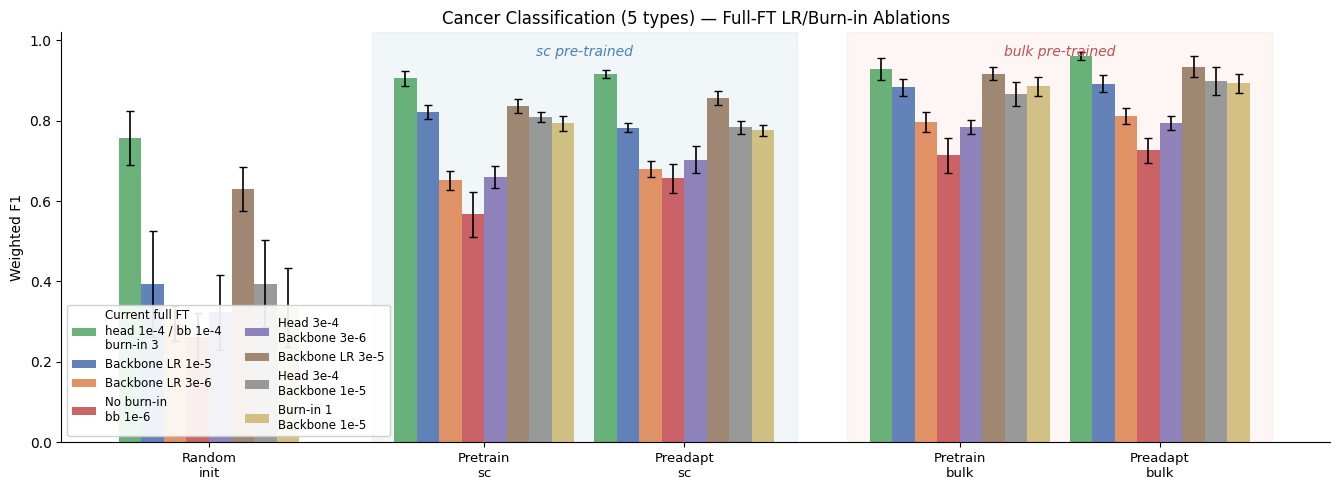

In [246]:
task = "canc_type_class"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
variants = [
    "full_ft",
    "full_ft_bb1e5",
    "full_ft_bb3e6",
    "full_ft_no_burnin",
    "full_ft_head3e4_bb3e6",
    "full_ft_bb3e5",
    "full_ft_head3e4_bb1e5",
    "full_ft_burnin1_bb1e5",
]
variant_labels = {
    "full_ft": "Current full FT\nhead 1e-4 / bb 1e-4\nburn-in 3",
    "full_ft_bb1e5": "Backbone LR 1e-5",
    "full_ft_bb3e6": "Backbone LR 3e-6",
    "full_ft_no_burnin": "No burn-in\nbb 1e-6",
    "full_ft_head3e4_bb3e6": "Head 3e-4\nBackbone 3e-6",
    "full_ft_bb3e5": "Backbone LR 3e-5",
    "full_ft_head3e4_bb1e5": "Head 3e-4\nBackbone 1e-5",
    "full_ft_burnin1_bb1e5": "Burn-in 1\nBackbone 1e-5",
}
colors = {
    "full_ft": "#55A868",
    "full_ft_bb1e5": "#4C72B0",
    "full_ft_bb3e6": "#DD8452",
    "full_ft_no_burnin": "#C44E52",
    "full_ft_head3e4_bb3e6": "#8172B3",
    "full_ft_bb3e5": "#937860",
    "full_ft_head3e4_bb1e5": "#8C8C8C",
    "full_ft_burnin1_bb1e5": "#CCB974",
}


def load_variant(variant):
    path = f"{base}/{variant}/{task}_{variant}_evaluation_metrics.csv"
    if os.path.exists(path):
        return pd.read_csv(path, comment="#").set_index("model")
    return None


dfs = {variant: load_variant(variant) for variant in variants}
available_variants = [variant for variant in variants if dfs[variant] is not None]
if not available_variants:
    raise FileNotFoundError(f"No full-FT ablation metric files found under {base}")

bar_w = min(0.16, 0.72 / max(len(available_variants), 1))
centers = {
    "random_init": 0.0,
    "pretrain_sc": 1.1,
    "preadapt_sc": 1.9,
    "pretrain_bulk": 3.0,
    "preadapt_bulk": 3.8,
}

fig, ax = plt.subplots(figsize=(13.5, 5))

added = set()
for variant_idx, variant in enumerate(available_variants):
    offset = (variant_idx - (len(available_variants) - 1) / 2) * bar_w
    df = dfs[variant]
    for model, xc in centers.items():
        if df is None or model not in df.index:
            continue
        if "f1_weighted_mean" not in df.columns:
            continue
        mean = df.loc[model, "f1_weighted_mean"]
        std = df.loc[model, "f1_weighted_std"] if "f1_weighted_std" in df.columns else 0.0
        label = variant_labels[variant] if variant not in added else ""
        ax.bar(
            xc + offset, mean, bar_w, yerr=std, color=colors[variant],
            capsize=3, alpha=0.88, label=label,
            error_kw={"linewidth": 1.2},
        )
        added.add(variant)

sc_lo, sc_hi = centers["pretrain_sc"] - 0.45, centers["preadapt_sc"] + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
ax.axvspan(sc_lo, sc_hi, alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon", zorder=0)
y_top = ax.get_ylim()[1]
ax.text((sc_lo + sc_hi) / 2, y_top * 0.97, "sc pre-trained",
        color="steelblue", ha="center", va="top", fontsize=10, style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_top * 0.97, "bulk pre-trained",
        color="#C44E52", ha="center", va="top", fontsize=10, style="italic")

ax.set_xticks(list(centers.values()))
ax.set_xticklabels([
    "Random\ninit", "Pretrain\nsc", "Preadapt\nsc",
    "Pretrain\nbulk", "Preadapt\nbulk",
], fontsize=9.5)
ax.set_ylabel("Weighted F1")
ax.set_title("Cancer Classification (5 types) — Full-FT LR/Burn-in Ablations")
ax.legend(loc="lower left", fontsize=8.5, framealpha=0.9, ncol=2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Cancer classification (33 types)

In [247]:
bulkrnabert_weighted_f1_mean = 0.942
bulkrnabert_weighted_f1_sd = 0.004
bulkformer_weighted_f1_mean = 0.833
geneformer_weighted_f1_mean = 0.473
genecompass_weighted_f1_mean = 0.761
scgpt_weighted_f1_mean = 0.83
scfoundation_weighted_f1_mean = 0.791
sclong_weighted_f1_mean = 0.347

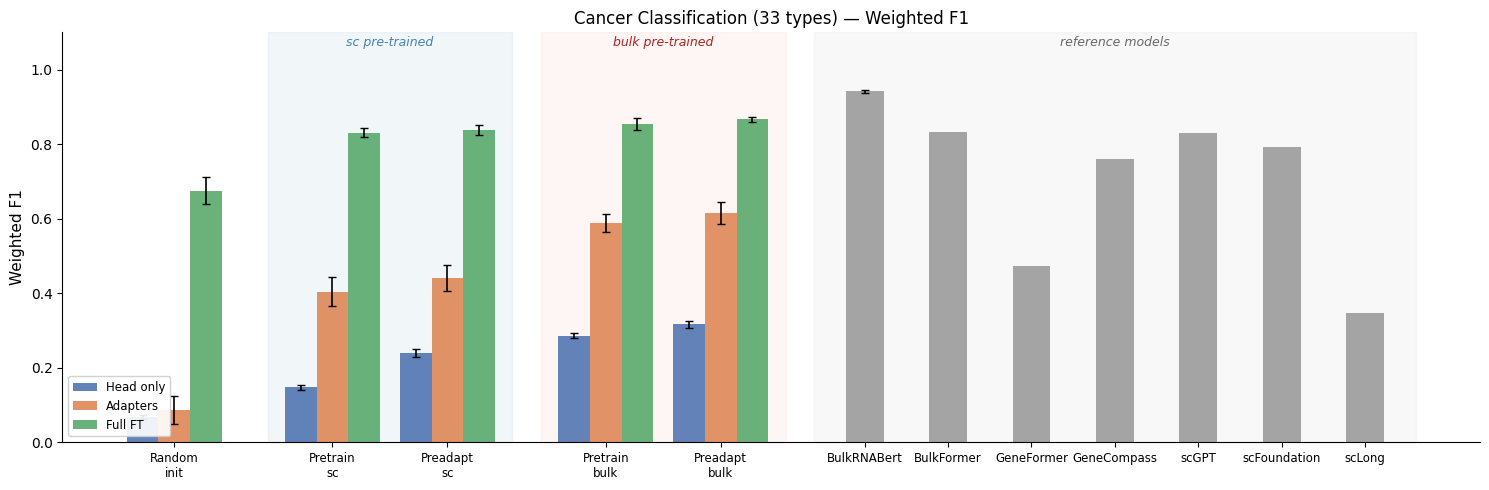

In [248]:
task = "canc_type_class_33"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft"]
mode_labels = {"head_only": "Head only", "adapters": "Adapters", "full_ft": "Full FT"}
colors  = {"head_only": "#4C72B0", "adapters": "#DD8452", "full_ft": "#55A868"}

dfs = {}
for mode in modes:
    path = f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv"
    if os.path.exists(path):
        dfs[mode] = pd.read_csv(path, comment="#").set_index("model")
available_modes = [mode for mode in modes if mode in dfs]
if not available_modes:
    raise FileNotFoundError(f"No evaluation metric files found under {base}")

bar_w = 0.22
centers = {
    "random_init":  0.0,
    "pretrain_sc":  1.1,
    "preadapt_sc":  1.9,
    "pretrain_bulk": 3.0,
    "preadapt_bulk": 3.8,
}

ref_models = [
    ("BulkRNABert",  bulkrnabert_weighted_f1_mean,  bulkrnabert_weighted_f1_sd),
    ("BulkFormer",   bulkformer_weighted_f1_mean,   None),
    ("GeneFormer",   geneformer_weighted_f1_mean,   None),
    ("GeneCompass",  genecompass_weighted_f1_mean,  None),
    ("scGPT",        scgpt_weighted_f1_mean,        None),
    ("scFoundation", scfoundation_weighted_f1_mean, None),
    ("scLong",       sclong_weighted_f1_mean,        None),
]
ref_start, ref_spacing = 4.8, 0.58
ref_x = [ref_start + i * ref_spacing for i in range(len(ref_models))]

fig, ax = plt.subplots(figsize=(15, 5))

added = set()
for m_idx, mode in enumerate(available_modes):
    offset = (m_idx - (len(available_modes) - 1) / 2) * bar_w
    for model, xc in centers.items():
        if model not in dfs[mode].index:
            continue
        mean = dfs[mode].loc[model, "f1_weighted_mean"]
        std  = dfs[mode].loc[model, "f1_weighted_std"]
        lbl  = mode_labels[mode] if mode not in added else ""
        ax.bar(xc + offset, mean, bar_w, yerr=std, color=colors[mode],
               capsize=3, alpha=0.88, label=lbl, error_kw={"linewidth": 1.2})
        added.add(mode)

for i, (name, mean, sd) in enumerate(ref_models):
    ax.bar(ref_x[i], mean, bar_w * 1.2, yerr=sd, color="#999999",
           capsize=3, alpha=0.88, label="_nolegend_",
           error_kw={"linewidth": 1.2} if sd else {})

sc_lo,   sc_hi   = centers["pretrain_sc"]  - 0.45, centers["preadapt_sc"]  + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
ref_lo,  ref_hi  = ref_x[0] - 0.35, ref_x[-1] + 0.35
ax.axvspan(sc_lo,   sc_hi,   alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon",    zorder=0)
ax.axvspan(ref_lo,  ref_hi,  alpha=0.05, color="gray",      zorder=0)

y_lim = (0, 1.1)
ax.set_ylim(*y_lim)

ax.text((sc_lo + sc_hi) / 2,     y_lim[1] - 0.01, "sc pre-trained",
        ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_lim[1] - 0.01, "bulk pre-trained",
        ha="center", va="top", fontsize=9, color="firebrick", style="italic")
ax.text((ref_lo + ref_hi) / 2,   y_lim[1] - 0.01, "reference models",
        ha="center", va="top", fontsize=9, color="dimgray", style="italic")

tick_pos    = list(centers.values()) + ref_x
tick_labels = ["Random\ninit", "Pretrain\nsc", "Preadapt\nsc",
               "Pretrain\nbulk", "Preadapt\nbulk"] + [n for n, _, _ in ref_models]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=8.5)

ax.set_ylabel("Weighted F1", fontsize=11)
ax.set_title("Cancer Classification (33 types) — Weighted F1", fontsize=12)
ax.legend(loc="lower left", fontsize=8.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Deconvolution

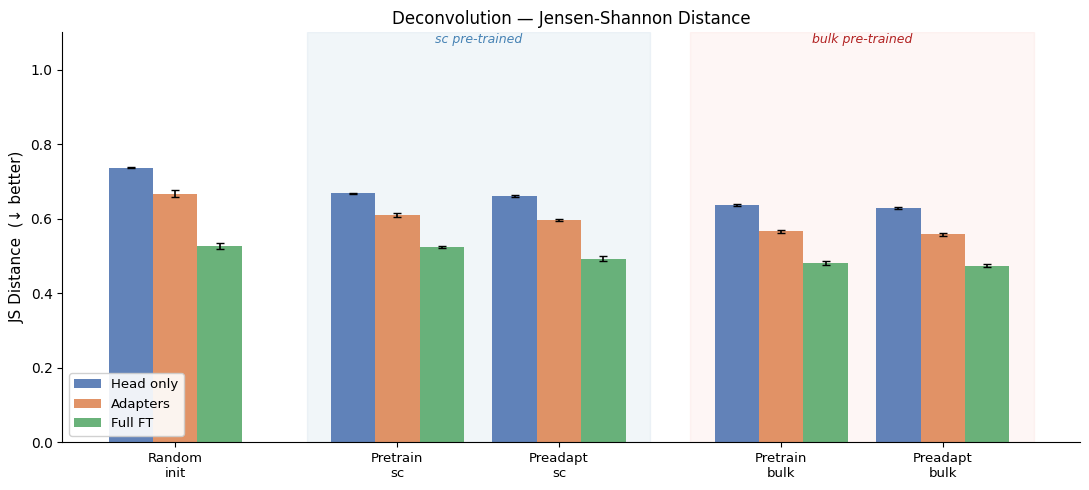

In [249]:
task = "deconv"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft"]
mode_labels = {"head_only": "Head only", "adapters": "Adapters", "full_ft": "Full FT"}
colors = {"head_only": "#4C72B0", "adapters": "#DD8452", "full_ft": "#55A868"}

model_keys  = ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]
metric_mean = "js_distance_mean"
metric_std  = "js_distance_std"

def load_mode(mode):
    combined = f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv"
    if os.path.exists(combined):
        return pd.read_csv(combined, comment="#").set_index("model")
    parts = [pd.read_csv(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv", comment="#")
             for m in model_keys
             if os.path.exists(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv")]
    return pd.concat(parts).set_index("model") if parts else None

dfs = {mode: load_mode(mode) for mode in modes}
available_modes = [mode for mode in modes if dfs[mode] is not None]
if not available_modes:
    raise FileNotFoundError(f"No evaluation metric files found under {base}")

bar_w = 0.22
centers = {
    "random_init":  0.0,
    "pretrain_sc":  1.1,
    "preadapt_sc":  1.9,
    "pretrain_bulk": 3.0,
    "preadapt_bulk": 3.8,
}

fig, ax = plt.subplots(figsize=(11, 5))

added = set()
for m_idx, mode in enumerate(available_modes):
    offset = (m_idx - (len(available_modes) - 1) / 2) * bar_w
    df = dfs[mode]
    for model, xc in centers.items():
        if df is None or model not in df.index:
            continue
        mean = df.loc[model, metric_mean]
        std  = df.loc[model, metric_std]
        lbl  = mode_labels[mode] if mode not in added else ""
        ax.bar(xc + offset, mean, bar_w, yerr=std, color=colors[mode],
               capsize=3, alpha=0.88, label=lbl, error_kw={"linewidth": 1.2})
        added.add(mode)

sc_lo,   sc_hi   = centers["pretrain_sc"]  - 0.45, centers["preadapt_sc"]  + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
ax.axvspan(sc_lo,   sc_hi,   alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon",    zorder=0)

y_lim = (0, 1.1)
ax.set_ylim(*y_lim)

ax.text((sc_lo + sc_hi) / 2,     y_lim[1] - 0.003, "sc pre-trained",
        ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_lim[1] - 0.003, "bulk pre-trained",
        ha="center", va="top", fontsize=9, color="firebrick", style="italic")

ax.set_xticks(list(centers.values()))
ax.set_xticklabels(["Random\ninit", "Pretrain\nsc", "Preadapt\nsc",
                    "Pretrain\nbulk", "Preadapt\nbulk"], fontsize=9.5)

ax.set_ylabel("JS Distance  (↓ better)", fontsize=11)
ax.set_title("Deconvolution — Jensen-Shannon Distance", fontsize=12)
ax.legend(loc="lower left", fontsize=9.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Disease classification

In [250]:
bulkformer_weighted_f1_mean = 0.939
geneformer_weighted_f1_mean = 0.749
genecompass_weighted_f1_mean = 0.882
scgpt_weighted_f1_mean = 0.885
scfoundation_weighted_f1_mean = 0.874
sclong_weighted_f1_mean = 0.81

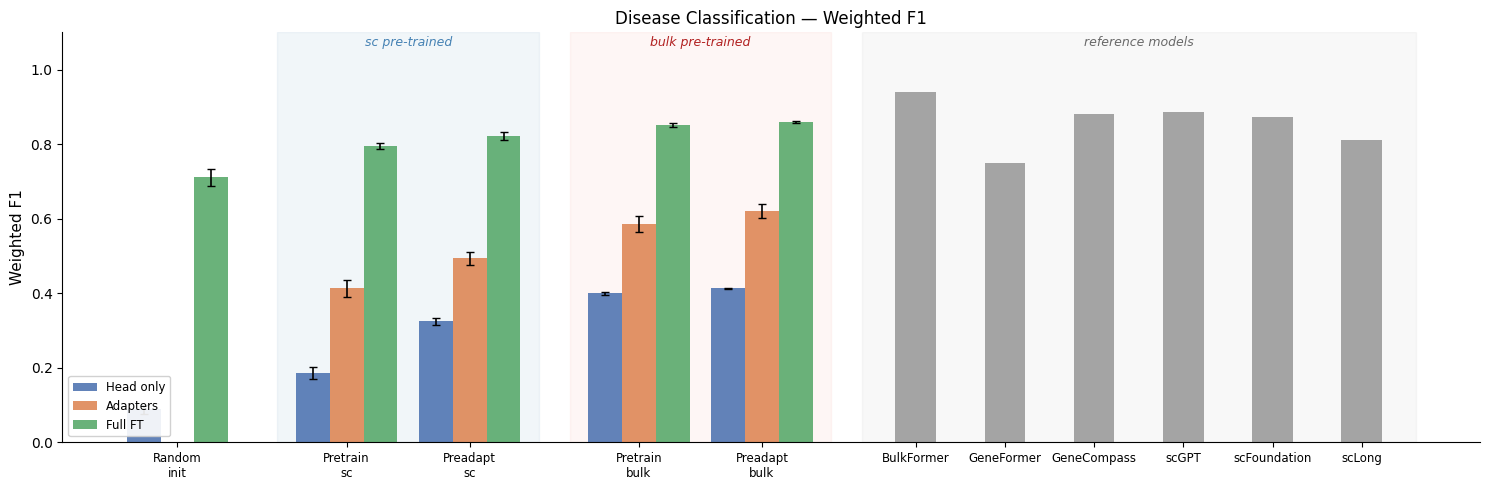

In [251]:
task = "disease_class"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft"]
mode_labels = {"head_only": "Head only", "adapters": "Adapters", "full_ft": "Full FT"}
colors  = {"head_only": "#4C72B0", "adapters": "#DD8452", "full_ft": "#55A868"}
model_keys = ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]

def load_mode(mode):
    combined = f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv"
    if os.path.exists(combined):
        return pd.read_csv(combined, comment="#").set_index("model")
    parts = [pd.read_csv(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv", comment="#")
             for m in model_keys
             if os.path.exists(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv")]
    return pd.concat(parts).set_index("model") if parts else None

dfs = {mode: load_mode(mode) for mode in modes}
available_modes = [mode for mode in modes if dfs[mode] is not None]
if not available_modes:
    raise FileNotFoundError(f"No evaluation metric files found under {base}")

bar_w = 0.22
centers = {
    "random_init":  0.0,
    "pretrain_sc":  1.1,
    "preadapt_sc":  1.9,
    "pretrain_bulk": 3.0,
    "preadapt_bulk": 3.8,
}

ref_models = [
    ("BulkFormer",   bulkformer_weighted_f1_mean,   None),
    ("GeneFormer",   geneformer_weighted_f1_mean,   None),
    ("GeneCompass",  genecompass_weighted_f1_mean,  None),
    ("scGPT",        scgpt_weighted_f1_mean,        None),
    ("scFoundation", scfoundation_weighted_f1_mean, None),
    ("scLong",       sclong_weighted_f1_mean,        None),
]
ref_start, ref_spacing = 4.8, 0.58
ref_x = [ref_start + i * ref_spacing for i in range(len(ref_models))]

fig, ax = plt.subplots(figsize=(15, 5))

added = set()
for m_idx, mode in enumerate(available_modes):
    offset = (m_idx - (len(available_modes) - 1) / 2) * bar_w
    df = dfs[mode]
    for model, xc in centers.items():
        if df is None or model not in df.index:
            continue
        mean = df.loc[model, "f1_weighted_mean"]
        std  = df.loc[model, "f1_weighted_std"]
        lbl  = mode_labels[mode] if mode not in added else ""
        ax.bar(xc + offset, mean, bar_w, yerr=std, color=colors[mode],
               capsize=3, alpha=0.88, label=lbl, error_kw={"linewidth": 1.2})
        added.add(mode)

for i, (name, mean, sd) in enumerate(ref_models):
    ax.bar(ref_x[i], mean, bar_w * 1.2, color="#999999",
           alpha=0.88, label="_nolegend_")

sc_lo,   sc_hi   = centers["pretrain_sc"]  - 0.45, centers["preadapt_sc"]  + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
ref_lo,  ref_hi  = ref_x[0] - 0.35, ref_x[-1] + 0.35
ax.axvspan(sc_lo,   sc_hi,   alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon",    zorder=0)
ax.axvspan(ref_lo,  ref_hi,  alpha=0.05, color="gray",      zorder=0)

y_lim = (0, 1.1)
ax.set_ylim(*y_lim)

ax.text((sc_lo + sc_hi) / 2,     y_lim[1] - 0.01, "sc pre-trained",
        ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_lim[1] - 0.01, "bulk pre-trained",
        ha="center", va="top", fontsize=9, color="firebrick", style="italic")
ax.text((ref_lo + ref_hi) / 2,   y_lim[1] - 0.01, "reference models",
        ha="center", va="top", fontsize=9, color="dimgray", style="italic")

tick_pos    = list(centers.values()) + ref_x
tick_labels = ["Random\ninit", "Pretrain\nsc", "Preadapt\nsc",
               "Pretrain\nbulk", "Preadapt\nbulk"] + [n for n, _, _ in ref_models]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=8.5)

ax.set_ylabel("Weighted F1", fontsize=11)
ax.set_title("Disease Classification — Weighted F1", fontsize=12)
ax.legend(loc="lower left", fontsize=8.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Drug response prediction

In [252]:
bulkformer_pcc_mean = 0.91
geneformer_pcc_mean = 0.873
genecompass_pcc_mean = 0.872
scgpt_pcc_mean = 0.877
scfoundation_pcc_mean = 0.88
sclong_pcc_mean = 0.843

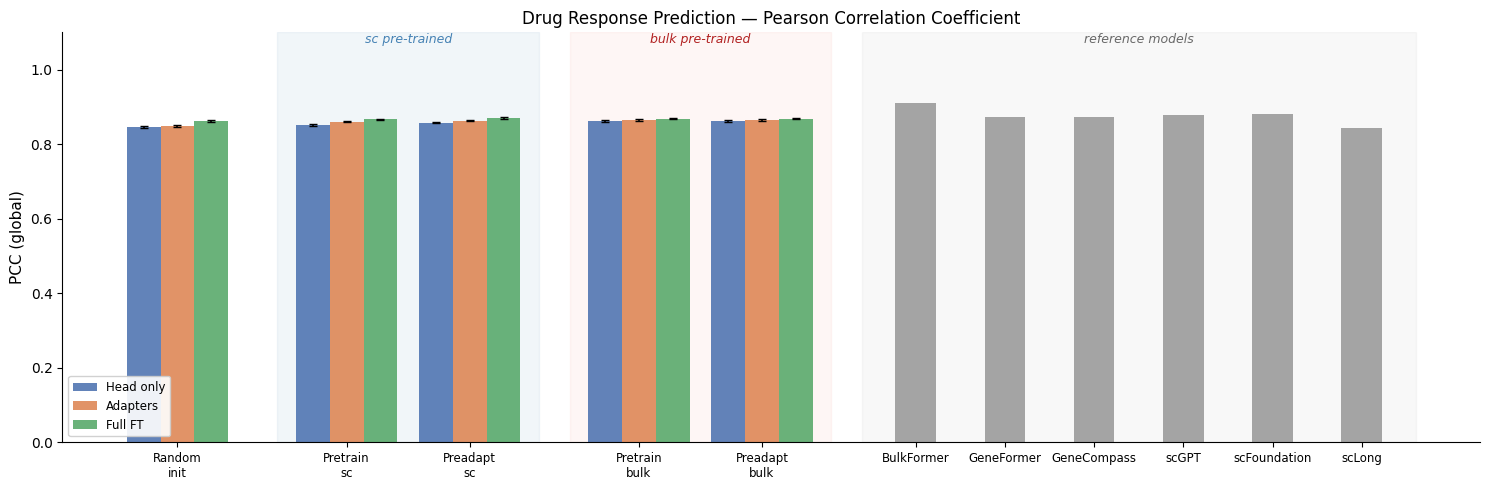

In [253]:
task = "drug_resp"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft"]
mode_labels = {"head_only": "Head only", "adapters": "Adapters", "full_ft": "Full FT"}
colors  = {"head_only": "#4C72B0", "adapters": "#DD8452", "full_ft": "#55A868"}
model_keys = ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]
metric_mean = "global_pcc_mean"
metric_std  = "global_pcc_std"

def load_mode(mode):
    combined = f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv"
    if os.path.exists(combined):
        return pd.read_csv(combined, comment="#").set_index("model")
    parts = [pd.read_csv(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv", comment="#")
             for m in model_keys
             if os.path.exists(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv")]
    return pd.concat(parts).set_index("model") if parts else None

dfs = {mode: load_mode(mode) for mode in modes}
available_modes = [mode for mode in modes if dfs[mode] is not None]
if not available_modes:
    raise FileNotFoundError(f"No evaluation metric files found under {base}")

bar_w = 0.22
centers = {
    "random_init":  0.0,
    "pretrain_sc":  1.1,
    "preadapt_sc":  1.9,
    "pretrain_bulk": 3.0,
    "preadapt_bulk": 3.8,
}

ref_models = [
    ("BulkFormer",   bulkformer_pcc_mean,   None),
    ("GeneFormer",   geneformer_pcc_mean,   None),
    ("GeneCompass",  genecompass_pcc_mean,  None),
    ("scGPT",        scgpt_pcc_mean,        None),
    ("scFoundation", scfoundation_pcc_mean, None),
    ("scLong",       sclong_pcc_mean,        None),
]
ref_start, ref_spacing = 4.8, 0.58
ref_x = [ref_start + i * ref_spacing for i in range(len(ref_models))]

fig, ax = plt.subplots(figsize=(15, 5))

added = set()
for m_idx, mode in enumerate(available_modes):
    offset = (m_idx - (len(available_modes) - 1) / 2) * bar_w
    df = dfs[mode]
    for model, xc in centers.items():
        if df is None or model not in df.index:
            continue
        mean = df.loc[model, metric_mean]
        std  = df.loc[model, metric_std]
        lbl  = mode_labels[mode] if mode not in added else ""
        ax.bar(xc + offset, mean, bar_w, yerr=std, color=colors[mode],
               capsize=3, alpha=0.88, label=lbl, error_kw={"linewidth": 1.2})
        added.add(mode)

for i, (name, mean, sd) in enumerate(ref_models):
    ax.bar(ref_x[i], mean, bar_w * 1.2, color="#999999",
           alpha=0.88, label="_nolegend_")

sc_lo,   sc_hi   = centers["pretrain_sc"]  - 0.45, centers["preadapt_sc"]  + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
ref_lo,  ref_hi  = ref_x[0] - 0.35, ref_x[-1] + 0.35
ax.axvspan(sc_lo,   sc_hi,   alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon",    zorder=0)
ax.axvspan(ref_lo,  ref_hi,  alpha=0.05, color="gray",      zorder=0)

y_lim = (0, 1.1)
ax.set_ylim(*y_lim)

ax.text((sc_lo + sc_hi) / 2,     y_lim[1] - 0.003, "sc pre-trained",
        ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_lim[1] - 0.003, "bulk pre-trained",
        ha="center", va="top", fontsize=9, color="firebrick", style="italic")
ax.text((ref_lo + ref_hi) / 2,   y_lim[1] - 0.003, "reference models",
        ha="center", va="top", fontsize=9, color="dimgray", style="italic")

tick_pos    = list(centers.values()) + ref_x
tick_labels = ["Random\ninit", "Pretrain\nsc", "Preadapt\nsc",
               "Pretrain\nbulk", "Preadapt\nbulk"] + [n for n, _, _ in ref_models]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=8.5)

ax.set_ylabel("PCC (global)", fontsize=11)
ax.set_title("Drug Response Prediction — Pearson Correlation Coefficient", fontsize=12)
ax.legend(loc="lower left", fontsize=8.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Gene essentiality prediction

In [254]:
bulkformer_pcc_mean = 0.931
geneformer_pcc_mean = 0.897
genecompass_pcc_mean = 0.881
scgpt_pcc_mean = 0.907
scfoundation_pcc_mean = 0.852
sclong_pcc_mean = 0.889

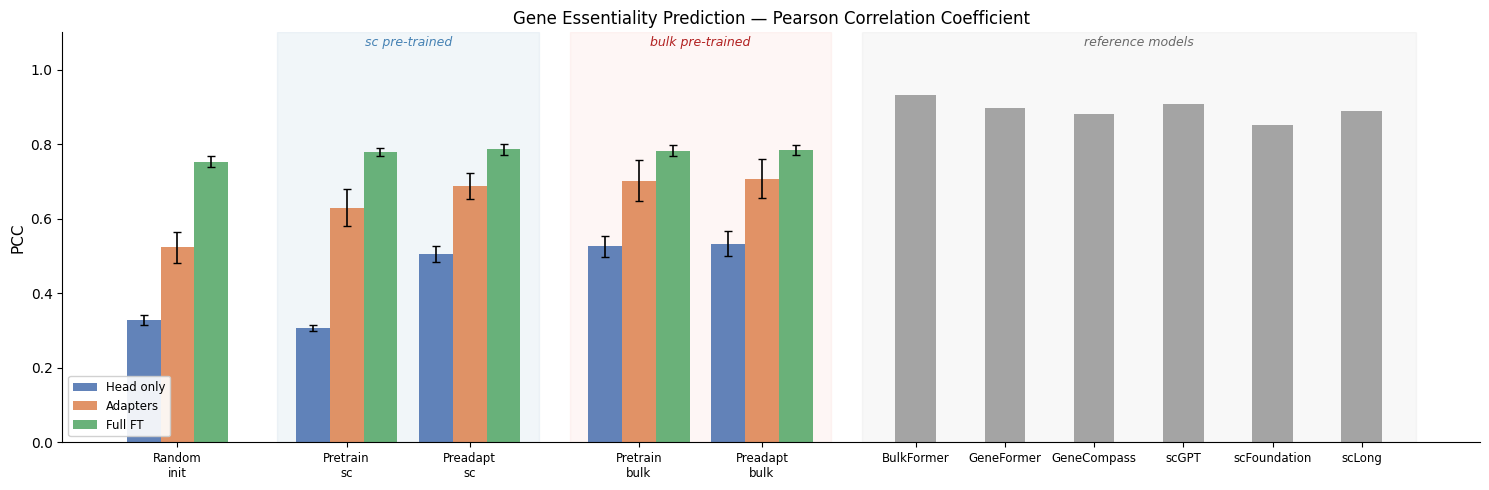

In [255]:
task = "gene_essent"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft"]
mode_labels = {"head_only": "Head only", "adapters": "Adapters", "full_ft": "Full FT"}
colors  = {"head_only": "#4C72B0", "adapters": "#DD8452", "full_ft": "#55A868"}
model_keys = ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]
metric_mean = "test_pcc_mean"
metric_std  = "test_pcc_std"

def load_mode(mode):
    combined = f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv"
    if os.path.exists(combined):
        return pd.read_csv(combined, comment="#").set_index("model")
    parts = [pd.read_csv(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv", comment="#")
             for m in model_keys
             if os.path.exists(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv")]
    return pd.concat(parts).set_index("model") if parts else None

dfs = {mode: load_mode(mode) for mode in modes}
available_modes = [mode for mode in modes if dfs[mode] is not None]
if not available_modes:
    raise FileNotFoundError(f"No evaluation metric files found under {base}")

bar_w = 0.22
centers = {
    "random_init":  0.0,
    "pretrain_sc":  1.1,
    "preadapt_sc":  1.9,
    "pretrain_bulk": 3.0,
    "preadapt_bulk": 3.8,
}

ref_models = [
    ("BulkFormer",   bulkformer_pcc_mean,   None),
    ("GeneFormer",   geneformer_pcc_mean,   None),
    ("GeneCompass",  genecompass_pcc_mean,  None),
    ("scGPT",        scgpt_pcc_mean,        None),
    ("scFoundation", scfoundation_pcc_mean, None),
    ("scLong",       sclong_pcc_mean,        None),
]
ref_start, ref_spacing = 4.8, 0.58
ref_x = [ref_start + i * ref_spacing for i in range(len(ref_models))]

fig, ax = plt.subplots(figsize=(15, 5))

added = set()
for m_idx, mode in enumerate(available_modes):
    offset = (m_idx - (len(available_modes) - 1) / 2) * bar_w
    df = dfs[mode]
    for model, xc in centers.items():
        if df is None or model not in df.index:
            continue
        mean = df.loc[model, metric_mean]
        std  = df.loc[model, metric_std]
        lbl  = mode_labels[mode] if mode not in added else ""
        ax.bar(xc + offset, mean, bar_w, yerr=std, color=colors[mode],
               capsize=3, alpha=0.88, label=lbl, error_kw={"linewidth": 1.2})
        added.add(mode)

for i, (name, mean, sd) in enumerate(ref_models):
    ax.bar(ref_x[i], mean, bar_w * 1.2, color="#999999",
           alpha=0.88, label="_nolegend_")

sc_lo,   sc_hi   = centers["pretrain_sc"]  - 0.45, centers["preadapt_sc"]  + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
ref_lo,  ref_hi  = ref_x[0] - 0.35, ref_x[-1] + 0.35
ax.axvspan(sc_lo,   sc_hi,   alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon",    zorder=0)
ax.axvspan(ref_lo,  ref_hi,  alpha=0.05, color="gray",      zorder=0)

y_lim = (0, 1.1)
ax.set_ylim(*y_lim)

ax.text((sc_lo + sc_hi) / 2,     y_lim[1] - 0.01, "sc pre-trained",
        ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_lim[1] - 0.01, "bulk pre-trained",
        ha="center", va="top", fontsize=9, color="firebrick", style="italic")
ax.text((ref_lo + ref_hi) / 2,   y_lim[1] - 0.01, "reference models",
        ha="center", va="top", fontsize=9, color="dimgray", style="italic")

tick_pos    = list(centers.values()) + ref_x
tick_labels = ["Random\ninit", "Pretrain\nsc", "Preadapt\nsc",
               "Pretrain\nbulk", "Preadapt\nbulk"] + [n for n, _, _ in ref_models]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=8.5)

ax.set_ylabel("PCC", fontsize=11)
ax.set_title("Gene Essentiality Prediction — Pearson Correlation Coefficient", fontsize=12)
ax.legend(loc="lower left", fontsize=8.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## Survival prediction

In [256]:
bulkrnabert_weighted_c_mean = 0.621
bulkrnabert_weighted_c_sd = 0.015

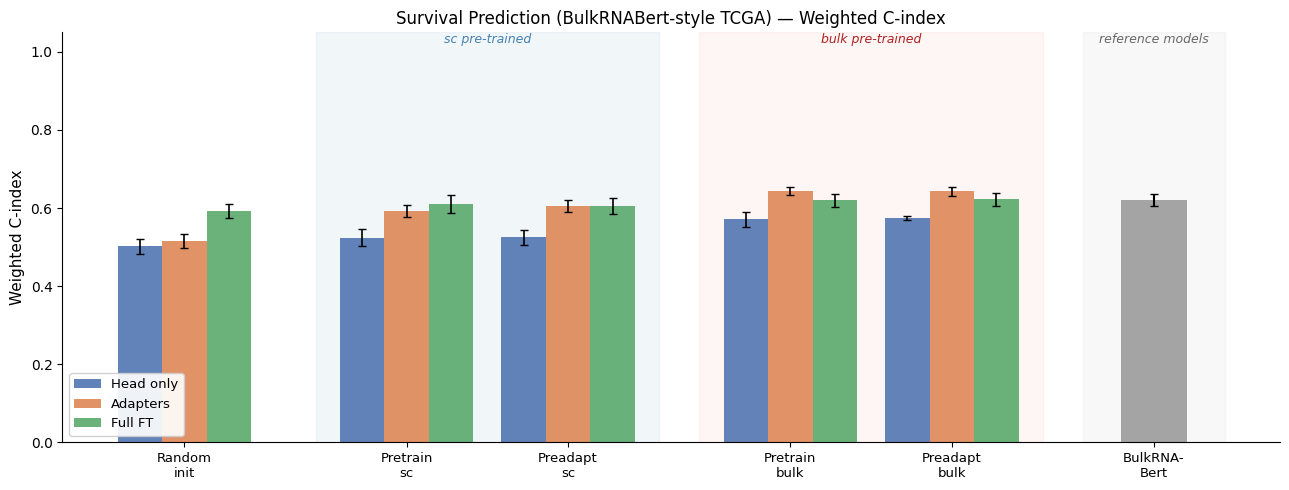

In [257]:

task = "surv_pred"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft"]
mode_labels = {"head_only": "Head only", "adapters": "Adapters", "full_ft": "Full FT"}
colors  = {"head_only": "#4C72B0", "adapters": "#DD8452", "full_ft": "#55A868"}
model_keys = ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]
metric_candidates = [
    ("test_cohort_weighted_c_index_mean", "test_cohort_weighted_c_index_std"),
    ("test_weighted_c_index_mean", "test_weighted_c_index_std"),  # old output fallback
]

def select_metric(df):
    for mean_col, std_col in metric_candidates:
        if mean_col in df.columns:
            return mean_col, std_col
    return None, None

def load_mode(mode):
    combined = f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv"
    if os.path.exists(combined):
        return pd.read_csv(combined, comment="#").set_index("model")
    parts = [
        pd.read_csv(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv", comment="#")
        for m in model_keys
        if os.path.exists(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv")
    ]
    return pd.concat(parts).set_index("model") if parts else None

dfs = {mode: load_mode(mode) for mode in modes}
available_modes = [mode for mode in modes if dfs[mode] is not None]
if not available_modes:
    raise FileNotFoundError(f"No survival prediction evaluation metric files found under {base}")

bar_w = 0.22
centers = {
    "random_init":  0.0,
    "pretrain_sc":  1.1,
    "preadapt_sc":  1.9,
    "pretrain_bulk": 3.0,
    "preadapt_bulk": 3.8,
}
brnabert_x = 4.8

fig, ax = plt.subplots(figsize=(13, 5))

added = set()
for m_idx, mode in enumerate(available_modes):
    offset = (m_idx - (len(available_modes) - 1) / 2) * bar_w
    df = dfs[mode]
    for model, xc in centers.items():
        if df is None or model not in df.index:
            continue
        metric_mean, metric_std = select_metric(df)
        if metric_mean is None:
            continue
        mean = df.loc[model, metric_mean]
        std = df.loc[model, metric_std] if metric_std in df.columns else 0.0
        lbl = mode_labels[mode] if mode not in added else ""
        ax.bar(
            xc + offset, mean, bar_w, yerr=std, color=colors[mode],
            capsize=3, alpha=0.88, label=lbl, error_kw={"linewidth": 1.2},
        )
        added.add(mode)

ax.bar(
    brnabert_x, bulkrnabert_weighted_c_mean, bar_w * 1.5,
    yerr=bulkrnabert_weighted_c_sd, capsize=3, color="#999999",
    alpha=0.88, label="_nolegend_",
)

sc_lo, sc_hi = centers["pretrain_sc"] - 0.45, centers["preadapt_sc"] + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
ref_lo, ref_hi = brnabert_x - 0.35, brnabert_x + 0.35
ax.axvspan(sc_lo, sc_hi, alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon", zorder=0)
ax.axvspan(ref_lo, ref_hi, alpha=0.05, color="gray", zorder=0)

y_lim = (0, 1.05)
ax.set_ylim(*y_lim)
ax.text((sc_lo + sc_hi) / 2, y_lim[1] - 0.001, "sc pre-trained",
        ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_lim[1] - 0.001, "bulk pre-trained",
        ha="center", va="top", fontsize=9, color="firebrick", style="italic")
ax.text((ref_lo + ref_hi) / 2, y_lim[1] - 0.001, "reference models",
        ha="center", va="top", fontsize=9, color="dimgray", style="italic")

tick_pos = list(centers.values()) + [brnabert_x]
tick_labels = [
    "Random\ninit", "Pretrain\nsc", "Preadapt\nsc",
    "Pretrain\nbulk", "Preadapt\nbulk", "BulkRNA-\nBert",
]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=9.5)
ax.set_ylabel("Weighted C-index", fontsize=11)
ax.set_title("Survival Prediction (BulkRNABert-style TCGA) — Weighted C-index", fontsize=12)
ax.legend(loc="lower left", fontsize=9.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()



## Survival prediction (SurvBoard)


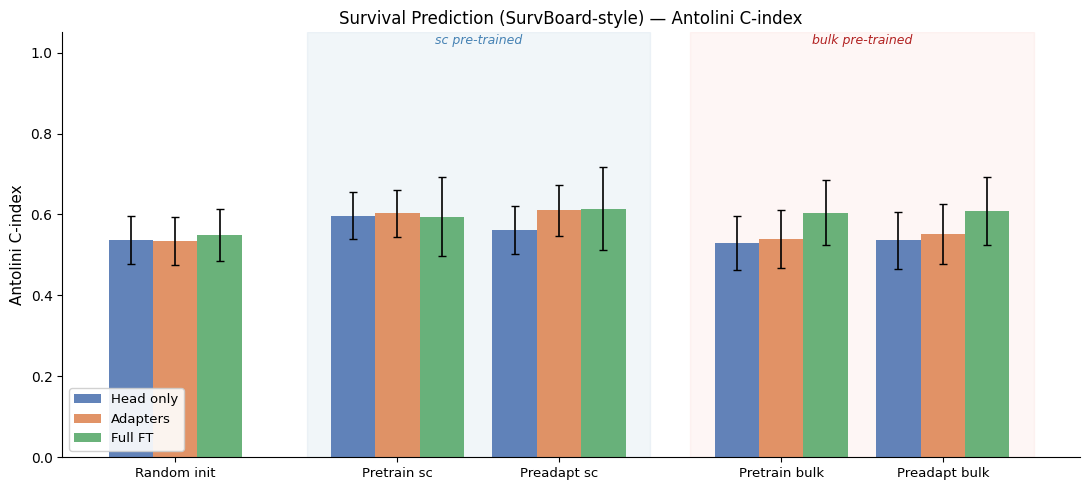

In [258]:

task = "surv_pred_survboard"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft"]
mode_labels = {"head_only": "Head only", "adapters": "Adapters", "full_ft": "Full FT"}
colors = {"head_only": "#4C72B0", "adapters": "#DD8452", "full_ft": "#55A868"}
model_keys = ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]
metric_mean = "test_antolini_cindex_mean"
metric_std = "test_antolini_cindex_std"


def load_mode(mode):
    combined = f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv"
    if os.path.exists(combined):
        return pd.read_csv(combined, comment="#").set_index("model")
    parts = [
        pd.read_csv(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv", comment="#")
        for m in model_keys
        if os.path.exists(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv")
    ]
    return pd.concat(parts).set_index("model") if parts else None


dfs = {mode: load_mode(mode) for mode in modes}
available_modes = [mode for mode in modes if dfs[mode] is not None]
if not available_modes:
    print(f"No SurvBoard survival prediction evaluation metric files found under {base}")
else:
    bar_w = 0.22
    centers = {
        "random_init": 0.0,
        "pretrain_sc": 1.1,
        "preadapt_sc": 1.9,
        "pretrain_bulk": 3.0,
        "preadapt_bulk": 3.8,
    }

    fig, ax = plt.subplots(figsize=(11, 5))
    added = set()
    for m_idx, mode in enumerate(available_modes):
        offset = (m_idx - (len(available_modes) - 1) / 2) * bar_w
        df = dfs[mode]
        for model, xc in centers.items():
            if df is None or model not in df.index or metric_mean not in df.columns:
                continue
            mean = df.loc[model, metric_mean]
            std = df.loc[model, metric_std] if metric_std in df.columns else 0.0
            label = mode_labels[mode] if mode not in added else ""
            ax.bar(
                xc + offset, mean, bar_w, yerr=std, color=colors[mode],
                capsize=3, alpha=0.88, label=label, error_kw={"linewidth": 1.2},
            )
            added.add(mode)

    sc_lo, sc_hi = centers["pretrain_sc"] - 0.45, centers["preadapt_sc"] + 0.45
    bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
    ax.axvspan(sc_lo, sc_hi, alpha=0.07, color="steelblue", zorder=0)
    ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon", zorder=0)
    ax.set_ylim(0, 1.05)
    ax.text((sc_lo + sc_hi) / 2, 1.045, "sc pre-trained", ha="center", va="top", fontsize=9, color="steelblue", style="italic")
    ax.text((bulk_lo + bulk_hi) / 2, 1.045, "bulk pre-trained", ha="center", va="top", fontsize=9, color="firebrick", style="italic")
    ax.set_xticks(list(centers.values()))
    ax.set_xticklabels(["Random init", "Pretrain sc", "Preadapt sc", "Pretrain bulk", "Preadapt bulk"], fontsize=9.5)
    ax.set_ylabel("Antolini C-index", fontsize=11)
    ax.set_title("Survival Prediction (SurvBoard-style) — Antolini C-index", fontsize=12)
    ax.legend(loc="lower left", fontsize=9.5, framealpha=0.9)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()



## Survival prediction (binary)

In [259]:
bulkformer_auroc_mean = 0.747
geneformer_auroc_mean = 0.647
genecompass_auroc_mean = 0.709
scgpt_auroc_mean = 0.723
scfoundation_auroc_mean = 0.726
sclong_auroc_mean = 0.584

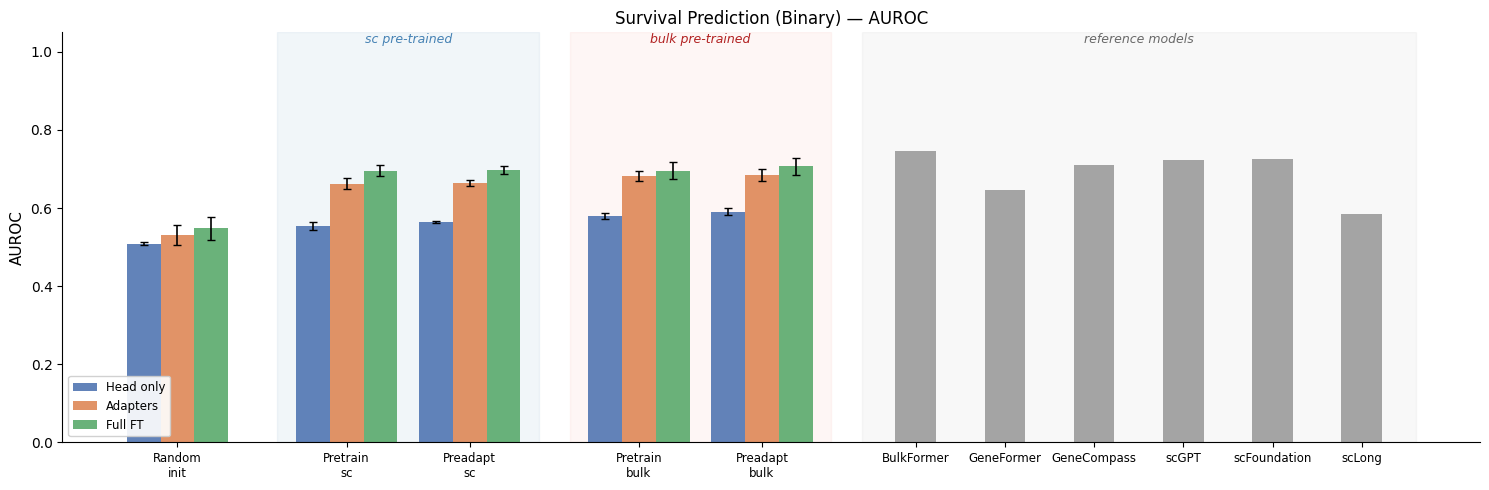

In [260]:

task = "surv_pred_binary"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft"]
mode_labels = {"head_only": "Head only", "adapters": "Adapters", "full_ft": "Full FT"}
colors  = {"head_only": "#4C72B0", "adapters": "#DD8452", "full_ft": "#55A868"}
model_keys = ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]
metric_mean = "auroc_mean"
metric_std  = "auroc_std"

def load_mode(mode):
    combined = f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv"
    if os.path.exists(combined):
        return pd.read_csv(combined, comment="#").set_index("model")
    parts = [
        pd.read_csv(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv", comment="#")
        for m in model_keys
        if os.path.exists(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv")
    ]
    return pd.concat(parts).set_index("model") if parts else None

dfs = {mode: load_mode(mode) for mode in modes}
available_modes = [mode for mode in modes if dfs[mode] is not None]
if not available_modes:
    raise FileNotFoundError(f"No binary survival prediction evaluation metric files found under {base}")

bar_w = 0.22
centers = {
    "random_init":  0.0,
    "pretrain_sc":  1.1,
    "preadapt_sc":  1.9,
    "pretrain_bulk": 3.0,
    "preadapt_bulk": 3.8,
}

ref_models = [
    ("BulkFormer",   bulkformer_auroc_mean,   None),
    ("GeneFormer",   geneformer_auroc_mean,   None),
    ("GeneCompass",  genecompass_auroc_mean,  None),
    ("scGPT",        scgpt_auroc_mean,        None),
    ("scFoundation", scfoundation_auroc_mean, None),
    ("scLong",       sclong_auroc_mean,       None),
]
ref_start, ref_spacing = 4.8, 0.58
ref_x = [ref_start + i * ref_spacing for i in range(len(ref_models))]

fig, ax = plt.subplots(figsize=(15, 5))

added = set()
for m_idx, mode in enumerate(available_modes):
    offset = (m_idx - (len(available_modes) - 1) / 2) * bar_w
    df = dfs[mode]
    for model, xc in centers.items():
        if df is None or model not in df.index or metric_mean not in df.columns:
            continue
        mean = df.loc[model, metric_mean]
        std = df.loc[model, metric_std] if metric_std in df.columns else 0.0
        lbl = mode_labels[mode] if mode not in added else ""
        ax.bar(
            xc + offset, mean, bar_w, yerr=std, color=colors[mode],
            capsize=3, alpha=0.88, label=lbl, error_kw={"linewidth": 1.2},
        )
        added.add(mode)

for i, (name, mean, sd) in enumerate(ref_models):
    ax.bar(ref_x[i], mean, bar_w * 1.2, color="#999999", alpha=0.88, label="_nolegend_")

sc_lo, sc_hi = centers["pretrain_sc"] - 0.45, centers["preadapt_sc"] + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
ref_lo, ref_hi = ref_x[0] - 0.35, ref_x[-1] + 0.35
ax.axvspan(sc_lo, sc_hi, alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon", zorder=0)
ax.axvspan(ref_lo, ref_hi, alpha=0.05, color="gray", zorder=0)

y_lim = (0, 1.05)
ax.set_ylim(*y_lim)
ax.text((sc_lo + sc_hi) / 2, y_lim[1] - 0.001, "sc pre-trained",
        ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_lim[1] - 0.001, "bulk pre-trained",
        ha="center", va="top", fontsize=9, color="firebrick", style="italic")
ax.text((ref_lo + ref_hi) / 2, y_lim[1] - 0.001, "reference models",
        ha="center", va="top", fontsize=9, color="dimgray", style="italic")

tick_pos = list(centers.values()) + ref_x
tick_labels = [
    "Random\ninit", "Pretrain\nsc", "Preadapt\nsc",
    "Pretrain\nbulk", "Preadapt\nbulk",
] + [name for name, _, _ in ref_models]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=8.5)
ax.set_ylabel("AUROC", fontsize=11)
ax.set_title("Survival Prediction (Binary) — AUROC", fontsize=12)
ax.legend(loc="lower left", fontsize=8.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()
